In [50]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import scipy.io as io
import sys

global_path = "/home/ids/edabier/HSU"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

import src.utils.utils as utils
import src.utils.losses as losses
import src.utils.plots as plots
import src.utils.extractor as extractor
import src.models.models as models
import src.models.foundation_models as rsfm

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

Using device: cuda:0


In [51]:
dataset = "jasper"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float32)
E = torch.tensor(data["E"])
A_flat = torch.tensor(data["A"])
B, c, N = E.shape[0], E.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat).unsqueeze(0)
A = utils.oneD_to_2d(A_flat).unsqueeze(0)
H = Y_init.shape[-1]

if dataset == "urban4":
    with open(f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt", "r") as file:
        lines = file.readlines()
        wavelengths = [float(line.strip()) for line in lines if line.strip()]

else:
    with open(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
        lines = file.readlines()
        wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [52]:
n_features = 1
fm, Y_init, new_H = rsfm.create_fm("DOFA", Y_init, n_features=n_features, use_cls=False, extend_cls=False, path=global_path)
features = rsfm.get_dofa_features(fm, Y_init, wavelengths)
D = int(features.shape[0]/1)

print(f"features: {features.shape}")

alpha = int(features.shape[1]**0.5)
unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=False)

features: torch.Size([768, 196])


### Unmixer vs CNNAEU SiVM

In [53]:
# loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
# epochs, lr = 200, 0.001

# optim_wrapper = dict(
#     optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.05),
#     constructor='LayerDecayOptimizerConstructor_ViT',
#     paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

# sads, sads_a, mses = [], [], []

# for n in range(20):

#     # E_init = extractor.SiVM(Y_init, c)
#     # E_init = utils.normalize(E_init, is_endmember=True)
#     # # model = rsfm.CNNAEU_with_decoder(B, c, E_init=E_init, freeze_E=False)
#     # model = models.CNNAEU(B, c, E_init=E_init)

#     model = unmixer
#     model.apply(model.weights_init)
#     model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True)
#     optimizer = build_optim_wrapper(model, optim_wrapper)

#     for epoch in range(epochs):
        
#         for Y, E, A in loader:
#             optimizer.zero_grad()
            
#             Y = utils.oneD_to_2d(Y).to(dev)
#             A = utils.oneD_to_2d(A).to(dev)
#             E = E.to(dev)

#             # E_hat, A_hat, Y_hat = model(Y)
#             # loss = model.loss(E, E_hat, A, A_hat, Y, Y_hat)

#             Y, A, features = rsfm.extract_f("DOFA", fm, Y, A, new_H, wavelengths, False)
#             E_hat, A_hat, Y_hat = model(features)
#             W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.5, 1e-4, 1e-3, 1e-7, 1e-3 #0.5, 0.2, 1e-2, 1e-7, 0
#             loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e, hypersigma=False)
            
#             # if epoch%(epochs//10)==0:
#             #     print(f"Epoch {epoch}: total = {format(loss, '.3f')}, SAD = {format(loss_sad, '.3f')}, MSE = {format(loss_mse, '.3f')}, Ab = {format(loss_ab, '.3f')}, TV_E = {format(loss_tv_e, '.3f')}, TV_A = {format(loss_tv_a, '.3f')}, Norm_E = {format(loss_norm_e, '.3f')}")
            
#             loss.backward()
#             optimizer.step()
            
#             with torch.no_grad():
#                 constraints = models.weightConstraint()
#                 model.decoder.apply(constraints)
#             break

#     # E_hat1, A_hat1, Y_hat1 = model(Y)
#     # A_hat1 = utils.oneD_to_2d(A_hat1)

#     _, A, features = rsfm.extract_f("DOFA", fm, Y_init, A, new_H, wavelengths, False)
#     E_hat1, A_hat1, Y_hat1 = model(features)

#     sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat1, A_hat1, A, E, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
#     sads.append(sad)
#     sads_a.append(sad_a)
#     mses.append(mse)
#     print(f"{n+1} xp done")

# sads_tensor = torch.tensor(sads)
# mses_tensor = torch.tensor(mses)
# sads_a_tensor = torch.tensor(sads_a)
# mses_tensor = mses_tensor[~mses_tensor.isnan()]
# sads_a_tensor = sads_a_tensor[~sads_a_tensor.isnan()]
# print(f"SAD = {format(torch.mean(sads_tensor), '.3f')} ± {format(torch.std(sads_tensor), '.2f')}, SAD (A) = {format(torch.mean(sads_a_tensor), '.3f')} ± {format(torch.std(sads_a_tensor), '.2f')}, NMSE = {format(torch.mean(mses_tensor), '.3f')} ± {format(torch.std(mses_tensor), '.2f')}, overall = {format(torch.mean(torch.tensor([torch.mean(mses_tensor), torch.mean(sads_tensor), torch.mean(sads_a_tensor)])), '.3f')}")

### CNNAEU A estimation

{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
After training: sad = 0.119, mse = 0.193, sad_a = 0.315, overall = 0.209
1 xp done
2 xp done
3 xp done
4 xp done
5 xp done
6 xp done
7 xp done
8 xp done
9 xp done
10 xp done
11 xp done
12 xp done
13 xp done
14 xp done
15 xp done
16 xp done
17 xp done
18 xp done
19 xp done
20 xp done
SAD = 0.119 ± 0.00, SAD (A) = 0.289 ± 0.12, NMSE = 0.133 ± 0.11, overall = 0.180


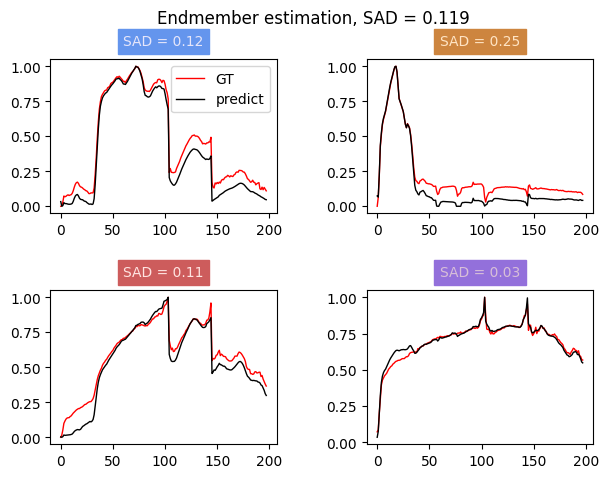

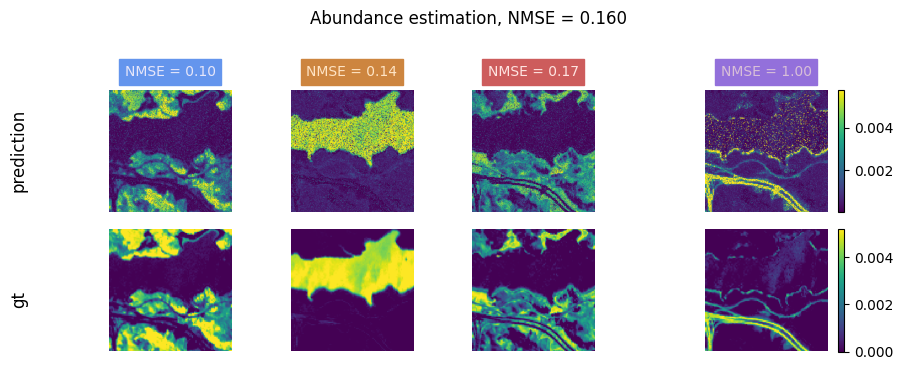

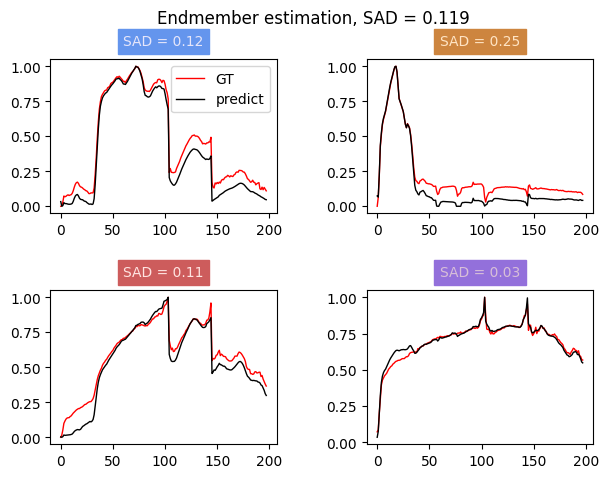

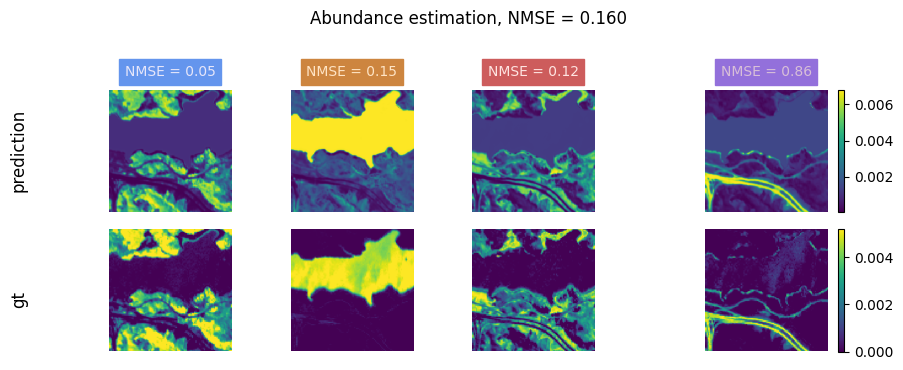

In [54]:
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
epochs, lr = 200, 0.001

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.05),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

model = unmixer
model.apply(model.weights_init)
model = models.init_decoder_weights(model, Y_init/Y_init.max(), c, is_unmixer=True)
optimizer = build_optim_wrapper(model, optim_wrapper)

for epoch in range(epochs):
    
    for Y, E, A in loader:
        optimizer.zero_grad()
        
        Y = utils.oneD_to_2d(Y).to(dev)
        A = utils.oneD_to_2d(A).to(dev)
        E = E.to(dev)

        Y, A, features = rsfm.extract_f("DOFA", fm, Y, A, new_H, wavelengths, False)
        E_hat, A_hat, Y_hat = model(features)
        W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.5, 1e-4, 1e-3, 1e-7, 1e-3 #0.5, 0.2, 1e-2, 1e-7, 0
        loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e, hypersigma=False)
        
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            constraints = models.weightConstraint()
            model.decoder.apply(constraints)
        break

_, A, features = rsfm.extract_f("DOFA", fm, Y_init, A, new_H, wavelengths, False)
E_hat1, A_hat1, Y_hat1 = model(features)
sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat1, A_hat1, A, E, normalize_E=True, normalize_A=True, return_results=True)
print(f"After training: sad = {format(sad, '.3f')}, mse = {format(mse, '.3f')}, sad_a = {format(sad_a, '.3f')}, overall = {format(torch.mean(torch.tensor([sad, sad_a, mse])), '.3f')}")

sads, sads_a, mses = [], [], []

for n in range(20):

    cnnaeu = rsfm.CNNAEU_with_decoder(B, c, model.decoder, freeze_E=True)
    state_dict = cnnaeu.decoder.state_dict()
    E_hat = model.decoder.get_endmembers()
    E_hat = utils.normalize(E_hat, is_endmember=True)
    state_dict["decoder.weight"] = E_hat.unsqueeze(-1).unsqueeze(-1)
    cnnaeu.decoder.load_state_dict(state_dict)

    epochs, lr = 200, 0.001
    optimizer = torch.optim.AdamW(cnnaeu.parameters(), lr=lr)

    for epoch in range(epochs):
        
        for Y_cnn, E_cnn, A_cnn in loader:
            optimizer.zero_grad()
            
            Y_cnn = Y_cnn.to(dev)
            # Y_cnn = utils.oneD_to_2d(Y_cnn)
            # Y_cnn = utils.sum_to_one(Y_cnn)
            # Y_cnn = Y_cnn/torch.max(Y_cnn)
            # Y_cnn = Y_cnn.flatten(2)

            E_hat_cnn, A_hat_cnn, Y_hat_cnn = cnnaeu(Y_cnn)

            loss = cnnaeu.loss(E_cnn, E_hat_cnn, A_cnn, A_hat_cnn, Y_cnn, Y_hat_cnn)

            loss.backward()
            optimizer.step()
            break

    E_hat_cnn, A_hat_cnn, Y_hat_cnn = cnnaeu(Y.reshape(1, B, new_H**2))
    A_hat_cnn = utils.oneD_to_2d(A_hat_cnn)

    sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_cnn, A_hat_cnn, A, E, normalize_E=True, normalize_A=True, return_results=True, plot_A=False, plot_E=False)
    sads.append(sad)
    sads_a.append(sad_a)
    mses.append(mse)
    print(f"{n+1} xp done")

sads = torch.tensor(sads)
mses = torch.tensor(mses)
sads_a = torch.tensor(sads_a)
sads_a = sads_a[~sads_a.isnan()]
plots.compute_metrics_and_plot(E_hat_cnn, A_hat_cnn, A, E, normalize_E=True, normalize_A=True)
print(f"SAD = {format(torch.mean(torch.tensor(sads)), '.3f')} ± {format(torch.std(torch.tensor(sads)), '.2f')}, SAD (A) = {format(torch.mean(torch.tensor(sads_a)), '.3f')} ± {format(torch.std(torch.tensor(sads_a)), '.2f')}, NMSE = {format(torch.mean(torch.tensor(mses)), '.3f')} ± {format(torch.std(torch.tensor(mses)), '.2f')}, overall = {format(torch.mean(torch.tensor([torch.mean(torch.tensor(mses)), torch.mean(torch.tensor(sads)), torch.mean(torch.tensor(sads_a))])), '.3f')}")